In [45]:
from sklearn.datasets import make_classification
import numpy as np
x,y=make_classification(n_samples=100,n_features=2,n_informative=1,n_redundant=0,n_classes=2,n_clusters_per_class=1,random_state=41,hypercube=False
                        ,class_sep=30)

In [46]:
import matplotlib.pyplot as plt

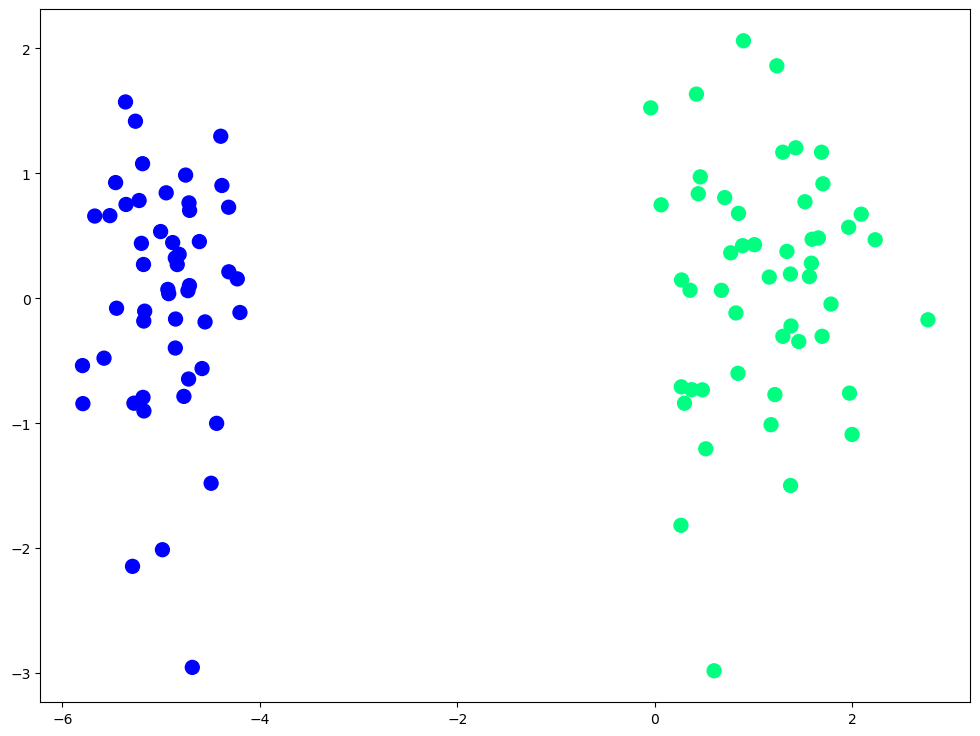

In [47]:
plt.figure(figsize=(12,9))
plt.scatter(x[:,0],x[:,1],c=y,cmap='winter',s=100)
plt.show()

In [48]:
def step(x):
    if(x>0):
        return 1
    return 0

In [49]:
def perceptron(x,y):
    x=np.insert(x,0,1,axis=1)
    weights=np.ones(x.shape[1])
    lr=0.1

    for i in range(1000):
        j=np.random.randint(0,100)
        y_hat=step(np.dot(x[j],weights)) # s
        weights=weights+lr*(y[j]-y_hat)*x[j]
    return weights[0],weights[1:]

In [50]:
intercept,coef=perceptron(x,y)

In [51]:
print(intercept)
print(coef)

1.2000000000000002
[1.08682872 0.52024363]


In [52]:
m= -(coef[0]/coef[1])
b= -(intercept / coef[1])
print(m)
print(b)

-2.0890764668062958
-2.3066116207171747


In [53]:
x_input=np.linspace(-3,3,100)
y_input=m * x_input + b

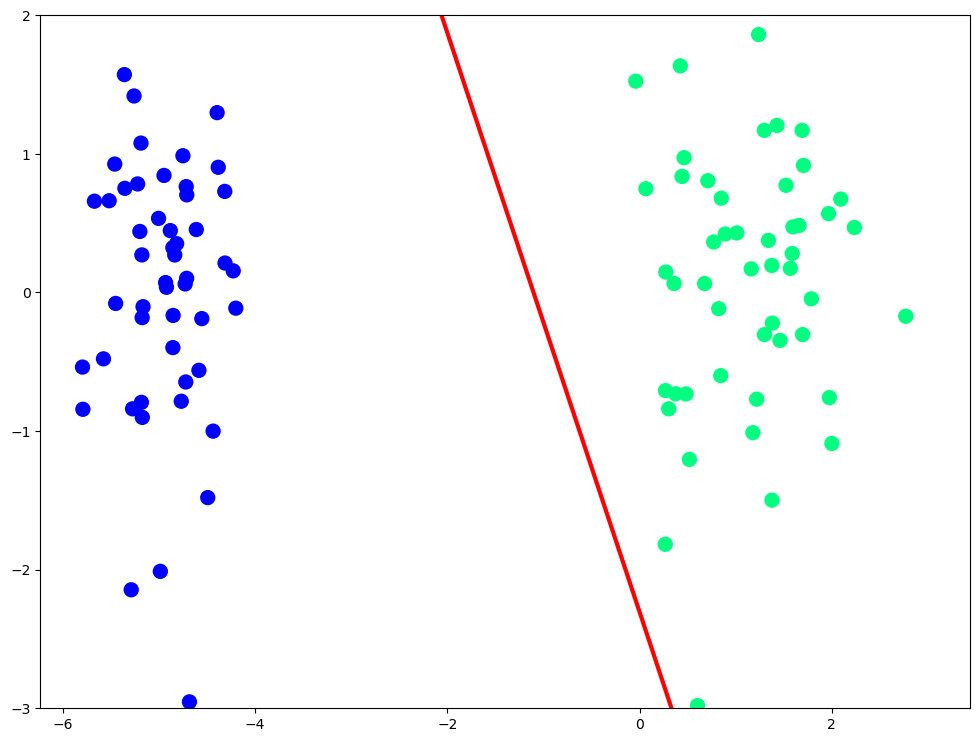

In [54]:
plt.figure(figsize=(12,9))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(x[:,0],x[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)
plt.show()


In [55]:
from sklearn.linear_model import LogisticRegression
lor=LogisticRegression()
lor.fit(x,y)

LogisticRegression()

In [56]:
lor.coef_

array([[1.77255101, 0.01190507]])

In [57]:
m= - (lor.coef_[0][0] / lor.coef_[0][1])
b= -(lor.intercept_ / lor.coef_[0][1])

In [58]:
x2_input=np.linspace(-3,3,100)
y2_input=m * x2_input + b

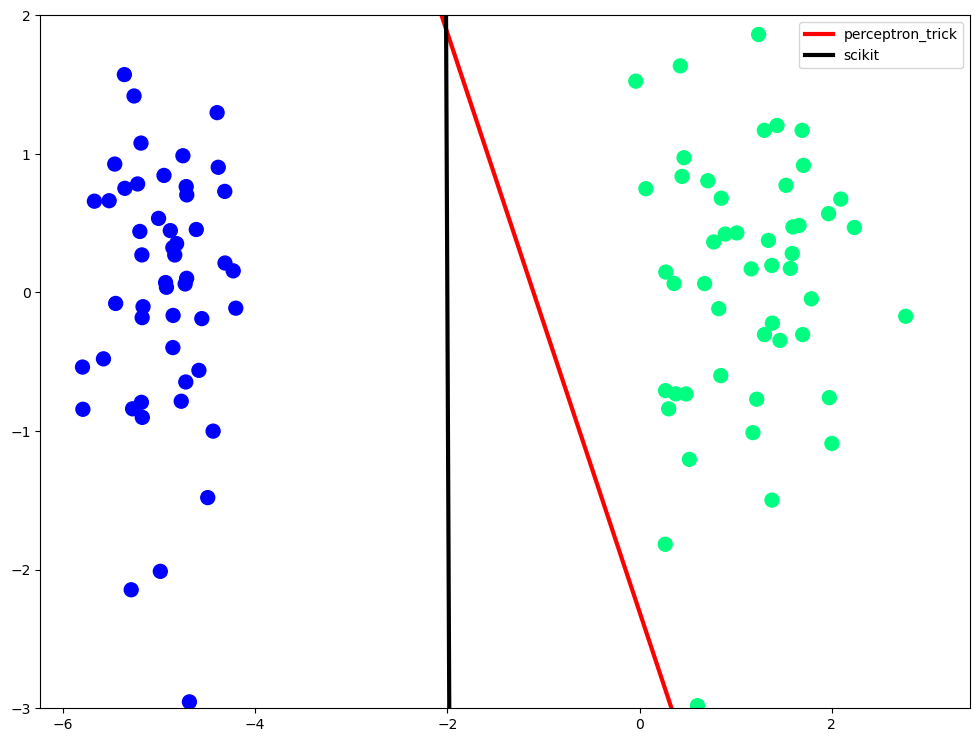

In [59]:
plt.figure(figsize=(12,9))
plt.plot(x_input,y_input,color='red',linewidth=3,label='perceptron_trick')
plt.plot(x2_input,y2_input,color='black',linewidth=3,label='scikit')
plt.scatter(x[:,0],x[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)
plt.legend()
plt.show()


In [60]:
def sigmoid(x):
    return 1/(1+np.exp(-x))

In [61]:
def perceptron(x,y):
    x=np.insert(x,0,1,axis=1)
    weights=np.ones(x.shape[1])
    lr=0.1

    for i in range(1000):
        j=np.random.randint(0,100)
        y_hat=sigmoid(np.dot(x[j],weights)) # s
        weights=weights+lr*(y[j]-y_hat)*x[j]
    return weights[0],weights[1:]

In [62]:
intercept,coef=perceptron(x,y)

In [63]:
print(intercept)
print(coef)

2.5867545875588736
[2.31600983 0.17257307]


In [64]:
m= -(coef[0]/coef[1])
b= -(intercept / coef[1])
print(m)
print(b)

-13.420458879497918
-14.989329097219516


In [65]:
x1_input=np.linspace(-3,3,100)
y1_input=m * x1_input + b

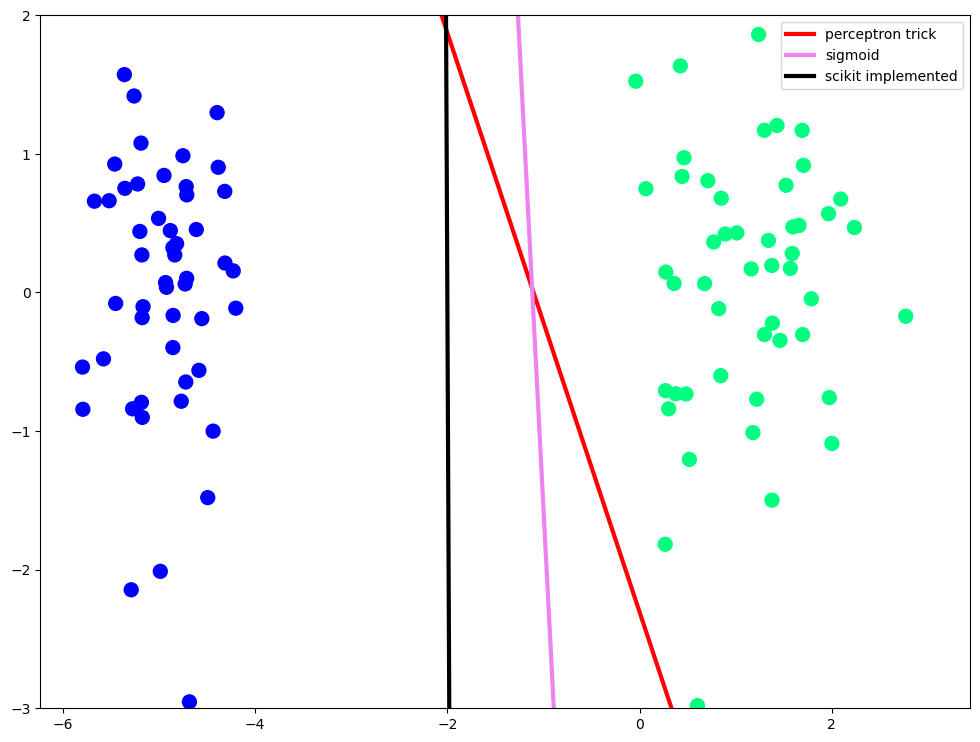

In [70]:
plt.figure(figsize=(12,9))
plt.plot(x_input,y_input,color='red',linewidth=3,label='perceptron trick')
plt.plot(x1_input,y1_input,color='violet',linewidth=3,label='sigmoid')
plt.plot(x2_input,y2_input,color='black',linewidth=3,label='scikit implemented')
plt.scatter(x[:,0],x[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)
plt.legend()
plt.show()


# still after using sigmoid , our model is not performing well as compared to the scikit implemented *(not optimized actually)*...let's refine it more !
because in machine learning, we do not find solution this way (the way we are using loop and randomly selecting -> not sure if it gives best fit line),
it always searches for a loss function(quantitative analysis of error being done by the model)
and tries to minimize it.